In [1]:
!pip install lmfit


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.1 -> 24.3.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [2]:
import lmfit

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import os
import pathlib
import glob

folder_name = "/home/sohom/new_project/all_myeloid(5_archetypes)/distance_and_ordering"
file_path = f"{folder_name}/cell_distances.csv"

# Load the data
data = pd.read_csv(file_path)

for j in range(data.shape[0]):
        # Save the histogram in a specific folder
        new_dir = pathlib.Path(f"{folder_name}/Archetype {j+1}")
        new_dir.mkdir(parents=True, exist_ok=True)
        df= data.iloc[j,:]
        y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
        plt.style.use('seaborn-white')
        plt.xlabel('Distance from Archetype',fontsize=10)
        plt.ylabel('Density',fontsize=10)
        plt.title(f'Distance from Archetype {j+1}',fontsize=14)
        plt.savefig('{}/histogram plot of distance distribution.pdf'.format(new_dir),dpi=300)
        plt.close()

/tmp/ipykernel_273810/4291845728.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')
/tmp/ipykernel_273810/4291845728.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')
/tmp/ipykernel_273810/4291845728.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn

In [4]:
data

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X26790,X26791,X26792,X26793,X26794,X26795,X26796,X26797,X26798,X26799
0,1,14.145928,14.685681,15.090805,15.692151,15.841851,15.854359,16.095624,16.160816,16.282450,...,71.043889,71.045583,71.052156,71.495837,71.575124,71.982387,72.293783,72.368544,72.380121,72.996373
1,2,15.812872,16.361458,17.100886,17.169144,19.199711,19.338539,19.926114,20.770594,21.257092,...,78.270532,78.412200,78.432406,78.556695,78.860429,78.895303,79.042983,79.332674,79.459773,79.498304
2,3,12.821257,14.010001,14.127097,14.960617,15.066325,15.269941,15.351996,15.486955,15.554569,...,68.935467,69.069869,69.247940,69.533191,69.712653,70.622678,71.420427,71.557401,71.862972,72.651924
3,4,14.912184,15.419651,15.627875,16.077779,16.157546,16.241012,16.796051,16.936305,17.393610,...,64.607397,64.683287,64.789359,64.941783,65.058786,65.356397,65.446863,65.488904,65.636108,66.488991
4,5,9.896606,10.552029,10.974271,11.011115,11.579606,11.589162,11.634666,11.702016,11.715775,...,70.653793,70.662211,70.802403,71.296926,71.382608,71.564790,72.579978,72.879612,73.394692,73.740180


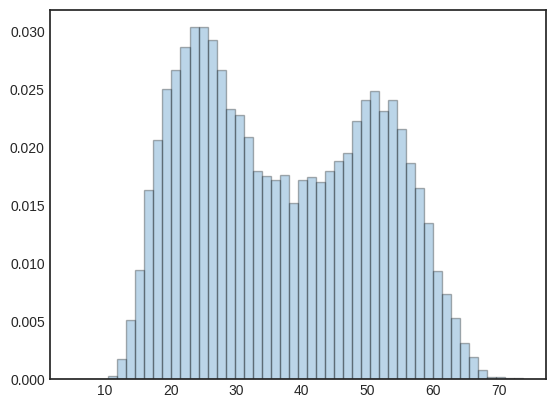

In [5]:
i=5
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [8]:
!pip install rpy2


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.1 -> 24.3.1
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [9]:
%reload_ext rpy2.ipython

In [10]:

%R install.packages('multimode')


* installing *source* package ‘multimode’ ...
** package ‘multimode’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0’
using Fortran compiler: ‘GNU Fortran (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0’


gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c BinDist2.c -o BinDist2.o
gfortran  -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong  -c  excmasapp.f90 -o excmasapp.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c multimode_init.c -o multimode_init.o
gcc -shared -L/usr/lib/R/lib -Wl,-Bsymbolic-functions -Wl,-z,relro -o multimode.so BinDist2.o excmasapp.o multimode_init.o -lgfortran -lm -lquadmath -L/usr/lib/R/lib -lR


installing to /home/sohom/R/x86_64-pc-linux-gnu-library/4.4/00LOCK-multimode/00new/multimode/libs
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (multimode)


Installing package into ‘/home/sohom/R/x86_64-pc-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/multimode_1.5.tar.gz'
Content type 'application/x-gzip' length 43077 bytes (42 KB)
downloaded 42 KB


The downloaded source packages are in
	‘/tmp/RtmpGKsWcs/downloaded_packages’
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [11]:
%R install.packages('mixtools')


* installing *source* package ‘mixtools’ ...
** package ‘mixtools’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0’


gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDEloc2.c -o KDEloc2.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDElocscale.c -o KDElocscale.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDErepeated.c -o KDErepeated.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDErepeatedbw.c -o KDErepeatedbw.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -

installing to /home/sohom/R/x86_64-pc-linux-gnu-library/4.4/00LOCK-mixtools/00new/mixtools/libs
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (mixtools)


Installing package into ‘/home/sohom/R/x86_64-pc-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/mixtools_2.0.0.tar.gz'
Content type 'application/x-gzip' length 706288 bytes (689 KB)
downloaded 689 KB


The downloaded source packages are in
	‘/tmp/RtmpGKsWcs/downloaded_packages’



	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.031542, p-value < 2.2e-16
alternative hypothesis: true number of modes is greater than 1

[1]  5.000099  7.411989 24.358626 35.188349 36.544896 38.750699 50.918851
number of iterations= 131 
        mu    sigma    lambda
1 25.28833 6.026254 0.4912648
2 48.96121 8.010309 0.5087352


mixtools package, version 2.0.0, Released 2022-12-04
This package is based upon work supported by the National Science Foundation under Grant No. SES-0518772 and the Chan Zuckerberg Initiative: Essential Open Source Software for Science (Grant No. 2020-255193).

In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


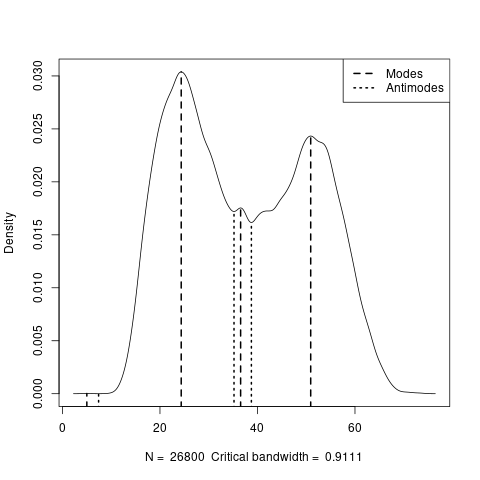

In [12]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=2)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

24.88911392797898
49.62488963604768


/tmp/ipykernel_273810/2218231540.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


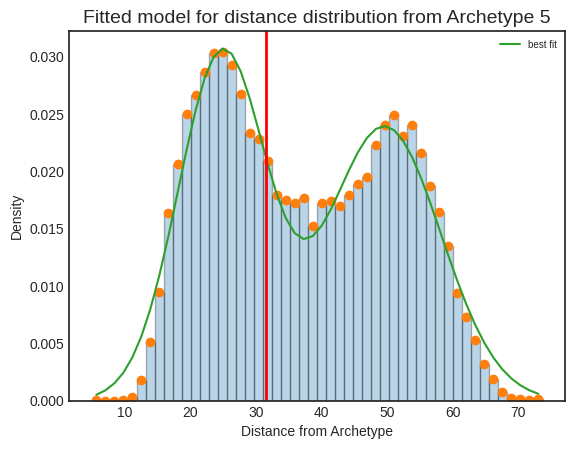

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"home/sohom/new_project/all_myeloid(5_archetypes)/Archetype 5", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

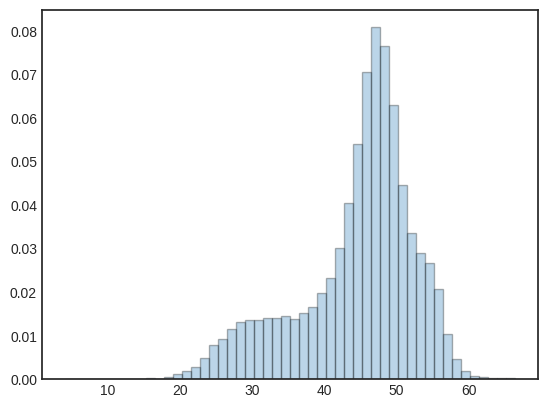

In [14]:
i=4
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.0017722, p-value = 0.824
alternative hypothesis: true number of modes is greater than 1

[1]  3.999547  9.455455 30.923178 32.165775 47.369078        NA        NA
number of iterations= 121 
        mu    sigma    lambda
1 31.57043 5.251959 0.2022318
2 47.77750 4.585989 0.7977682


In addition: Warning messages:
1: In excessmassex(data, mod0) :
  A modification of the data was made in order to compute the excess mass statistic
2: In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


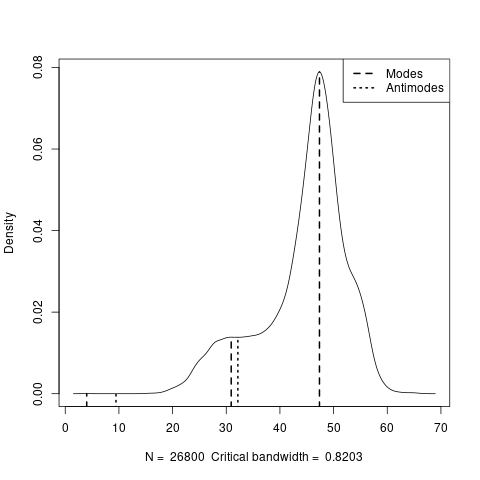

In [15]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=2)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

32.04665388588368
47.67855516299506


/tmp/ipykernel_273810/2252784669.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


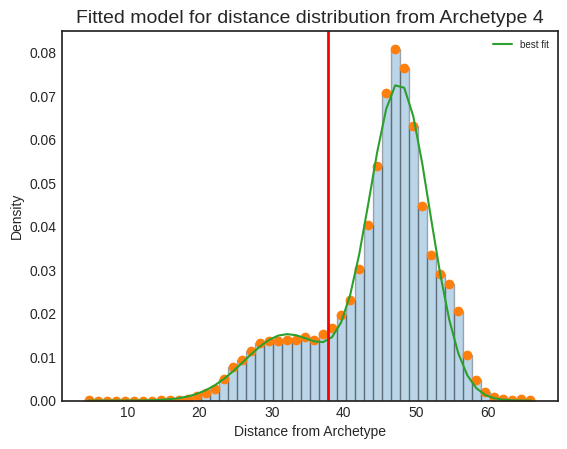

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"home/sohom/new_project/all_myeloid(5_archetypes)/Archetype 4", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

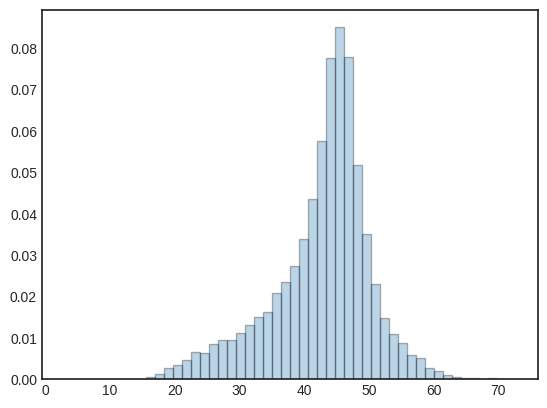

In [17]:
i=3
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [18]:
%%R -i df -o fit_result_unimod
library(MASS)
fit <- fitdistr(df, "normal")
para <- fit$estimate
para_mu<-para[1]
para_sigma <- para[2]
fit_result_unimod <- as.data.frame(cbind(para_mu,para_sigma))
fit_result_unimod

      para_mu para_sigma
mean 42.69776   7.672036



Attaching package: ‘MASS’

The following object is masked from ‘package:multimode’:

    geyser



/tmp/ipykernel_273810/2955608627.py:29: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


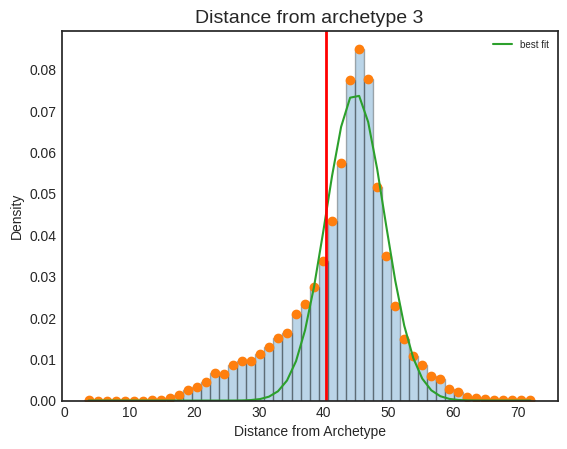

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model

import pathlib
new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"home/sohom/new_project/all_myeloid(5_archetypes)/Archetype 3", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir / f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

gmodel = Model(gauss)
result = gmodel.fit(y, x=x, A=0.8, mu=fit_result_unimod.iloc[0,0], sigma=fit_result_unimod.iloc[0,1])

cut_off_value =result.params['mu'].value - result.params['sigma'].value

result.fit_report()
plt.style.use('seaborn-white')
plt.plot(x, y, 'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Distance from archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

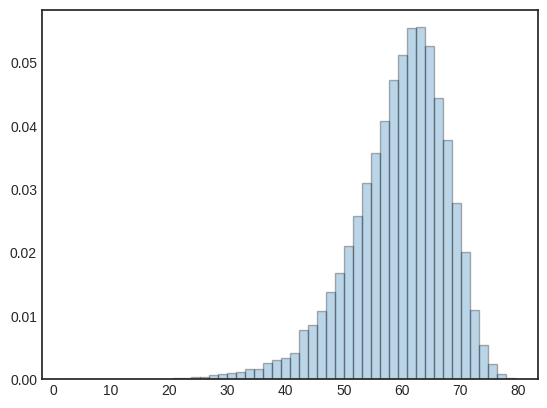

In [20]:
i=2
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [21]:
%%R -i df -o fit_result_unimod
library(MASS)
fit <- fitdistr(df, "normal")
para <- fit$estimate
para_mu<-para[1]
para_sigma <- para[2]
fit_result_unimod <- as.data.frame(cbind(para_mu,para_sigma))
fit_result_unimod

      para_mu para_sigma
mean 59.46507   8.173644


/tmp/ipykernel_273810/21062484.py:29: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


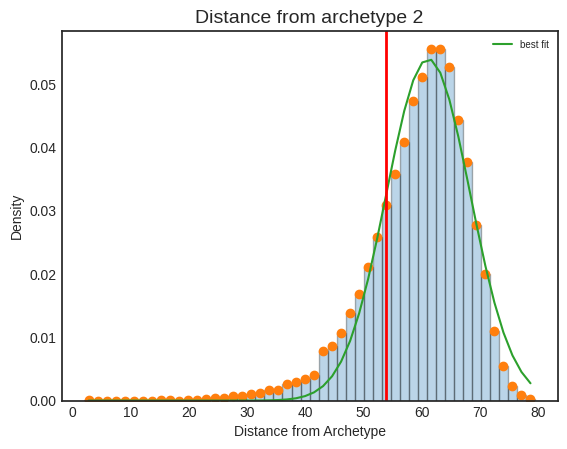

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model

import pathlib
new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"home/sohom/new_project/all_myeloid(5_archetypes)/Archetype 2", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir / f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

gmodel = Model(gauss)
result = gmodel.fit(y, x=x, A=0.8, mu=fit_result_unimod.iloc[0,0], sigma=fit_result_unimod.iloc[0,1])

cut_off_value =result.params['mu'].value - result.params['sigma'].value

result.fit_report()
plt.style.use('seaborn-white')
plt.plot(x, y, 'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Distance from archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

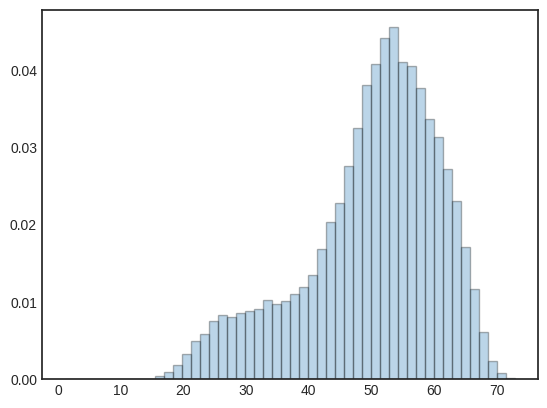

In [25]:
i=1
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.0016866, p-value = 0.952
alternative hypothesis: true number of modes is greater than 1

[1]  1.000168  7.565986  7.570735  7.573110  7.584983  7.587358 52.994799
number of iterations= 248 
        mu    sigma    lambda
1 31.97140 6.982155 0.1791932
2 53.86333 7.004464 0.8208068


In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


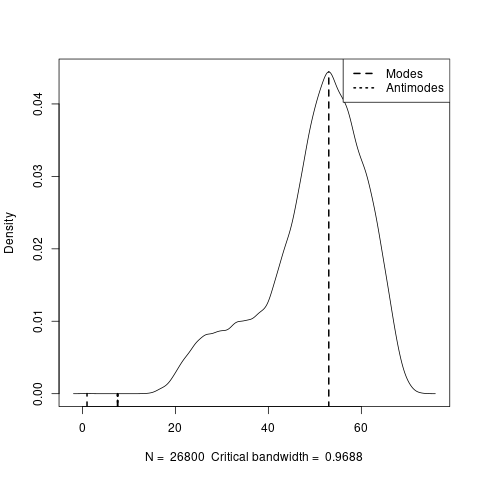

In [26]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=2)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

30.939716752384168
53.94514145325941


/tmp/ipykernel_273810/1617674117.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


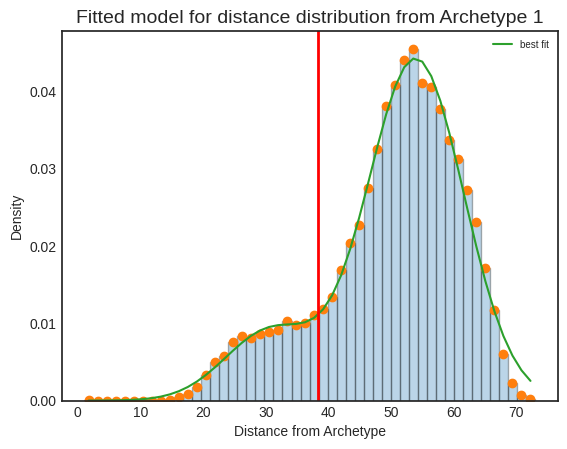

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"home/sohom/new_project/all_myeloid(5_archetypes)/Archetype 1", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

In [ ]:
i=2
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [ ]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=3)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_Epithelial/Archetype 2/{folder_name}", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   